# Day 3 / 60 — System Design Series
## Load Balancer + Vertical vs Horizontal Scaling

> *If server 1 goes offline, all traffic routes to server 2.*
> *If traffic grows beyond two servers, the load balancer adds more.*
> *This is horizontal scaling — the foundation of every large system.*

### What we cover today
1. Why a single web server is still a single point of failure after Day 2
2. Load balancer architecture — public IP, private IPs, server pool
3. How a load balancer routes traffic (Round Robin, Least Connections, IP Hash, Weighted)
4. Vertical Scaling vs Horizontal Scaling — definitions, limits, costs
5. Failover simulation — what happens when a server goes offline
6. Auto-scaling — dynamic pool growth under load
7. Key takeaways + what Day 4 brings


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE   = '#4C72B0'
C_GREEN  = '#55A868'
C_ORANGE = '#DD8452'
C_RED    = '#C44E52'
C_TEAL   = '#2E86AB'
C_PURPLE = '#9B59B6'
C_GOLD   = '#F0A500'
C_GRAY   = '#F8F9FA'
C_LB     = '#E67E22'

print("Libraries loaded. Day 3 ready.")


Libraries loaded. Day 3 ready.


### What this cell does
Imports the drawing libraries and defines a consistent colour palette for Day 3. `C_LB` (orange) is used exclusively for the load balancer so it stands out visually from the web servers (blue) and the user/DNS layer (teal). Consistent colour coding across all diagrams makes it easy to spot the same component in different contexts.


## 1 — The Problem: Still a Single Point of Failure

After Day 2 we separated the web tier from the data tier. But there is still only **one web server**. If that server crashes, the entire site goes down — we have just moved the single point of failure, not eliminated it.

The fix has two parts:
1. **Add a second web server** — so there is a backup
2. **Add a load balancer** — so traffic is distributed and failover is automatic

The load balancer becomes the **only public-facing IP**. Web servers move to **private IPs** — unreachable from the internet directly, which is also a significant security improvement.

```
Day 2 (problem):   User -> DNS -> Web Server (one machine, public IP) -> DB
Day 3 (solution):  User -> DNS -> Load Balancer (public IP 27.220.30.232)
                                  |-> Server 1 (private IP 10.0.0.1) -> DB
                                  |-> Server 2 (private IP 10.0.0.2) -> DB
```


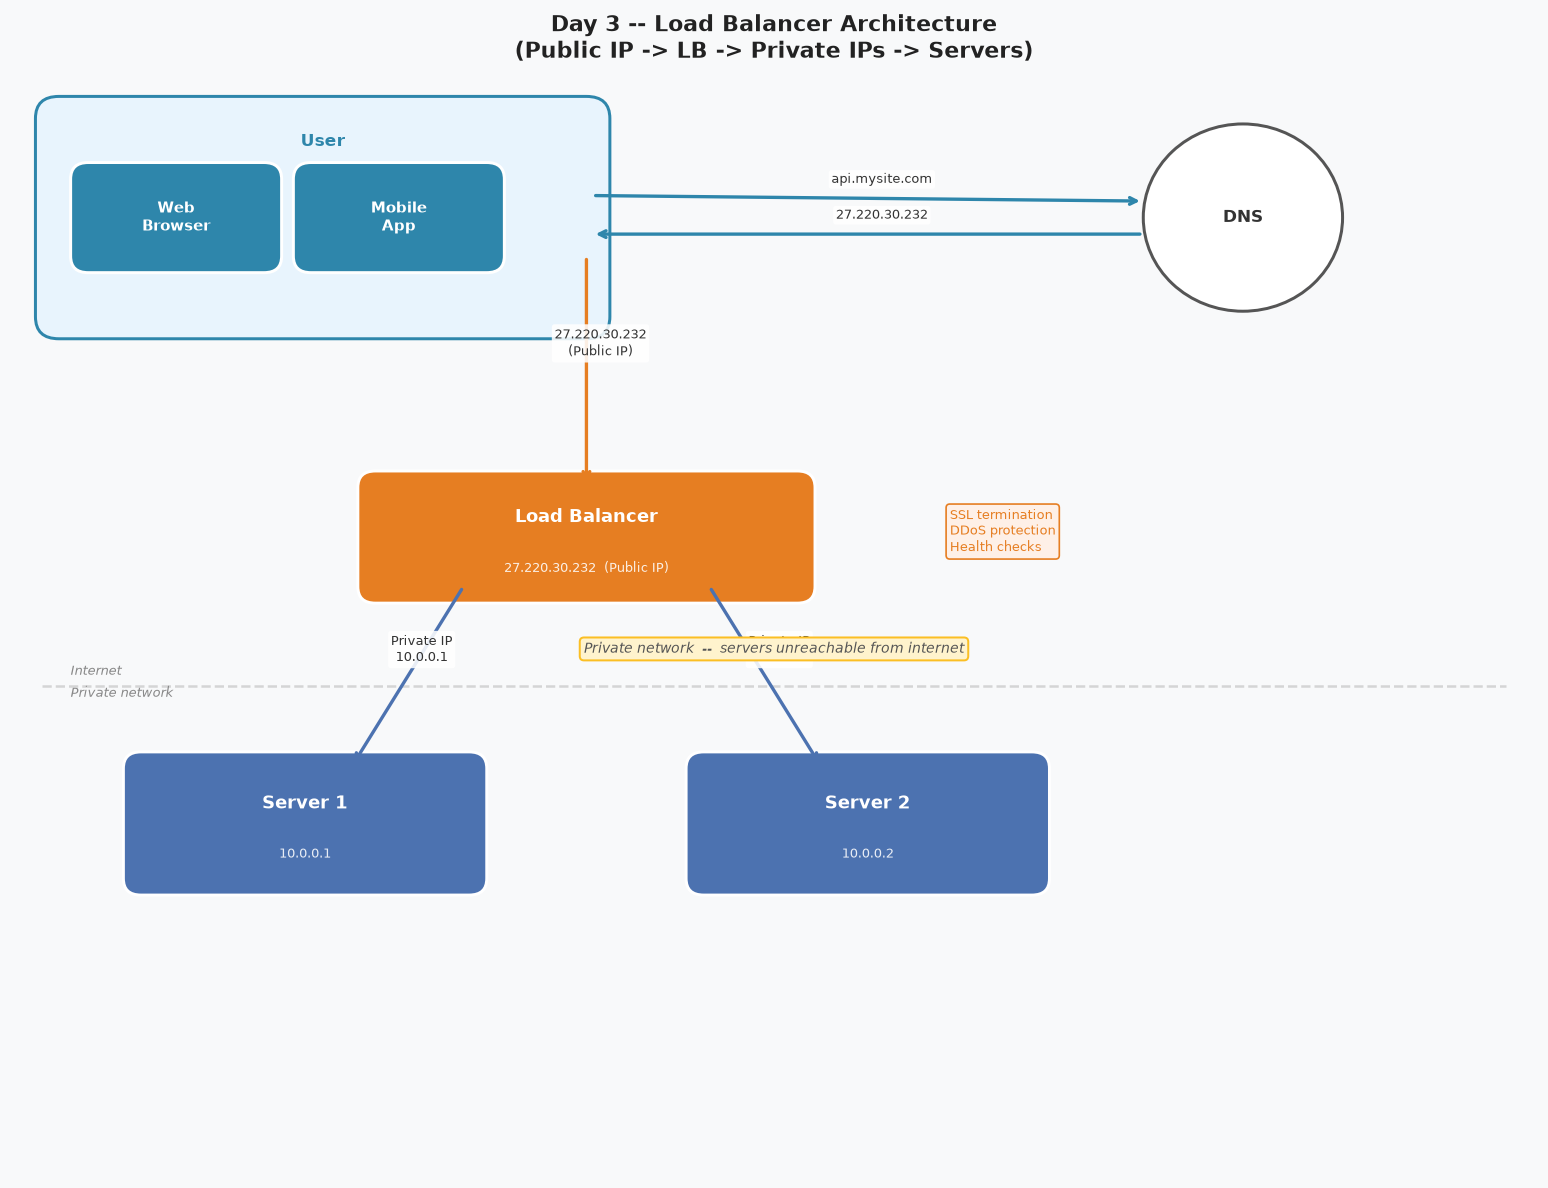

Architecture diagram complete.


In [2]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.set_xlim(0, 13); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor(C_GRAY)
fig.patch.set_facecolor(C_GRAY)

def box(ax, x, y, w, h, label, sub='', color=C_BLUE, fs=10, tc='white'):
    r = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.15',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y+(0.18 if sub else 0), label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tc)
    if sub:
        ax.text(x, y-0.28, sub, ha='center', va='center', fontsize=7.5,
                color=tc, alpha=0.88)

def arrow(ax, x1, y1, x2, y2, label='', lc='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=lc, lw=2.0))
    if label:
        ax.text((x1+x2)/2+0.12, (y1+y2)/2+0.14, label, ha='center',
                fontsize=8, color='#333',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.88, lw=0))

# User cluster (top left)
user_box = FancyBboxPatch((0.4, 7.8), 4.5, 1.8, boxstyle='round,pad=0.2',
                          facecolor='#E8F4FD', edgecolor=C_TEAL, lw=1.8)
ax.add_patch(user_box)
ax.text(2.65, 9.35, 'User', ha='center', fontsize=10,
        fontweight='bold', color=C_TEAL)
box(ax, 1.4, 8.7, 1.5, 0.7, 'Web\nBrowser', color=C_TEAL, fs=9)
box(ax, 3.3, 8.7, 1.5, 0.7, 'Mobile\nApp',  color=C_TEAL, fs=9)

# DNS (top right)
dns_circ = plt.Circle((10.5, 8.7), 0.85, facecolor='white',
                      edgecolor='#555', lw=1.8, zorder=3)
ax.add_patch(dns_circ)
ax.text(10.5, 8.7, 'DNS', ha='center', va='center', fontsize=10,
        fontweight='bold', color='#333', zorder=4)

# DNS arrows
arrow(ax, 4.95, 8.9, 9.65, 8.85, 'api.mysite.com', C_TEAL)
arrow(ax, 9.65, 8.55, 4.95, 8.55, '27.220.30.232', C_TEAL)

# Load Balancer
box(ax, 4.9, 5.8, 3.6, 0.9, 'Load Balancer',
    sub='27.220.30.232  (Public IP)', color=C_LB, fs=11)

# User -> LB arrow
arrow(ax, 4.9, 8.35, 4.9, 6.27, '27.220.30.232\n(Public IP)', C_LB)

# Web Servers
box(ax, 2.5, 3.2, 2.8, 1.0, 'Server 1', sub='10.0.0.1', color=C_BLUE, fs=11)
box(ax, 7.3, 3.2, 2.8, 1.0, 'Server 2', sub='10.0.0.2', color=C_BLUE, fs=11)

# LB -> Server arrows
arrow(ax, 3.85, 5.35, 2.9, 3.72, 'Private IP\n10.0.0.1', C_BLUE)
arrow(ax, 5.95, 5.35, 6.9, 3.72, 'Private IP\n10.0.0.2', C_BLUE)

# Security annotation
ax.text(6.5, 4.75,
        'Private network  --  servers unreachable from internet',
        ha='center', fontsize=8.5, color='#555', fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD',
                  edgecolor='#FBBF24', lw=1.2))

# Internet boundary
ax.axhline(4.45, xmin=0.02, xmax=0.98, color='#CCC', lw=1.5,
           linestyle='--', alpha=0.8)
ax.text(0.5, 4.55, 'Internet', fontsize=8, color='#888', fontstyle='italic')
ax.text(0.5, 4.35, 'Private network', fontsize=8, color='#888', fontstyle='italic')

# LB capabilities annotation
ax.text(8.0, 5.85, 'SSL termination\nDDoS protection\nHealth checks',
        fontsize=7.5, color=C_LB, va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF0E7',
                  edgecolor=C_LB, lw=1.0))

ax.set_title('Day 3 -- Load Balancer Architecture\n'
             '(Public IP -> LB -> Private IPs -> Servers)',
             fontsize=13, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day3_architecture.png', dpi=130, bbox_inches='tight')
plt.show()
print("Architecture diagram complete.")


### What this diagram shows
A faithful reproduction of the Day 3 reference diagram with added operational detail.

**Reading the diagram top to bottom:**
1. **User** (web browser or mobile app) types `api.mysite.com`
2. **DNS** resolves the domain to `27.220.30.232` — the **public IP of the load balancer**, not any web server
3. The HTTP request arrives at the **Load Balancer** at `27.220.30.232`
4. The LB forwards it to **Server 1** (`10.0.0.1`) or **Server 2** (`10.0.0.2`) via **private IPs**

**Why private IPs matter:**
- Web servers are completely invisible to the public internet
- An attacker who discovers the LB's IP still cannot directly reach any web server
- The load balancer centralises SSL termination, DDoS protection, and health checks

**The dashed boundary line** separates the public internet zone (above) from the private network (below). In AWS/GCP/Azure this becomes a **VPC (Virtual Private Cloud)** with subnet rules enforced by the cloud provider.


## 2 — Load Balancing Algorithms

Once the load balancer receives a request, it must decide **which server** to send it to. There are four main algorithms, each solving a different distribution problem.

| Algorithm | Routing rule | Best for |
|---|---|---|
| **Round Robin** | Rotate: S1, S2, S3, S1, S2... | Stateless apps, equal-weight requests |
| **Least Connections** | Send to server with fewest active connections | Long-lived connections (WebSockets, file uploads) |
| **IP Hash** | Hash(`client_ip`) % N | Session-sticky apps — same user always hits same server |
| **Weighted Round Robin** | S1 gets weight×more requests than S2 | Mixed hardware — new servers are more powerful |

**Health checks underpin all algorithms**: regardless of which algorithm is chosen, the load balancer continuously polls each server (`GET /health`). A server that fails N consecutive checks is removed from the pool until it recovers.


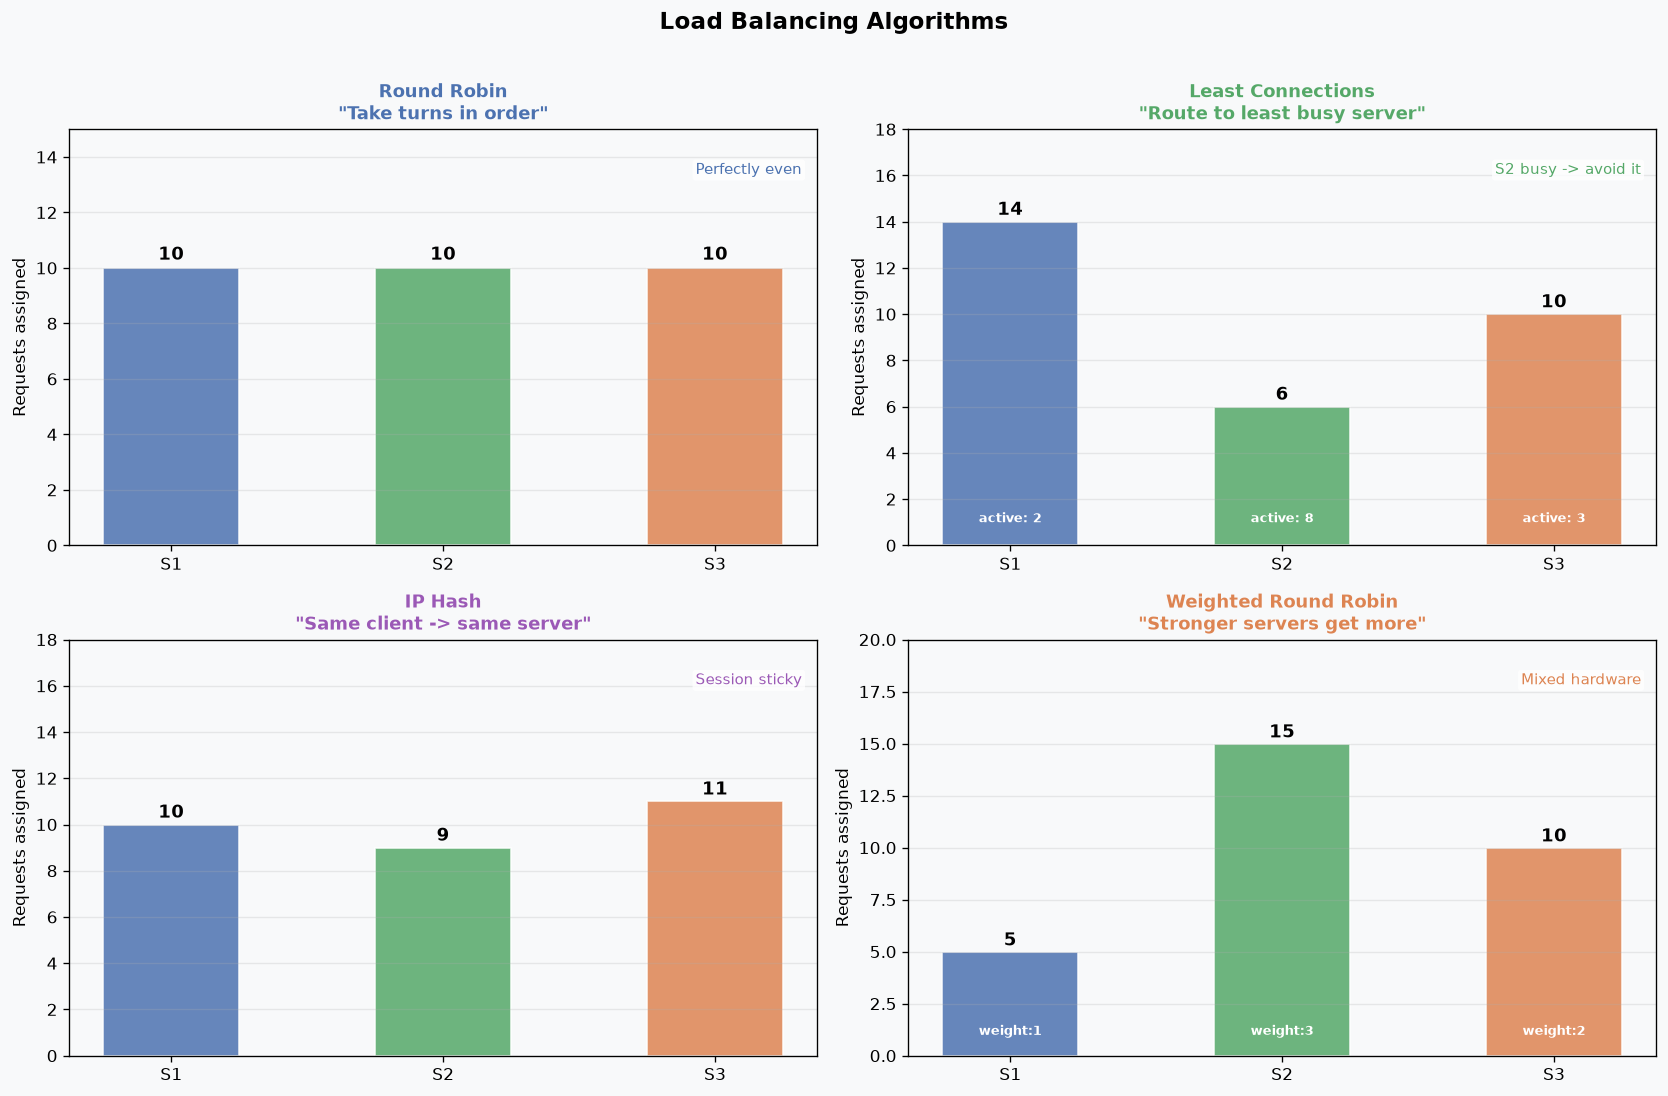

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)
plt.suptitle('Load Balancing Algorithms', fontsize=14, fontweight='bold', y=1.01)

np.random.seed(42)
n_requests = 30
servers = ['S1', 'S2', 'S3']

# Round Robin
ax = axes[0][0]
ax.set_facecolor(C_GRAY)
rr = [i % 3 for i in range(n_requests)]
counts = [rr.count(s) for s in range(3)]
ax.bar(servers, counts, color=[C_BLUE, C_GREEN, C_ORANGE], alpha=0.85,
       edgecolor='white', width=0.5)
for i, v in enumerate(counts):
    ax.text(i, v+0.3, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Round Robin\n"Take turns in order"', fontsize=11,
             fontweight='bold', color=C_BLUE)
ax.set_ylabel('Requests assigned'); ax.set_ylim(0, 15); ax.grid(axis='y', alpha=0.25)
ax.text(0.98, 0.92, 'Perfectly even', ha='right', va='top',
        transform=ax.transAxes, fontsize=9, color=C_BLUE,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, lw=0))

# Least Connections
ax = axes[0][1]
ax.set_facecolor(C_GRAY)
lc_dist = [14, 6, 10]
ax.bar(servers, lc_dist, color=[C_BLUE, C_GREEN, C_ORANGE], alpha=0.85,
       edgecolor='white', width=0.5)
for i, v in enumerate(lc_dist):
    ax.text(i, v+0.3, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Least Connections\n"Route to least busy server"', fontsize=11,
             fontweight='bold', color=C_GREEN)
ax.set_ylabel('Requests assigned'); ax.set_ylim(0, 18); ax.grid(axis='y', alpha=0.25)
active = [2, 8, 3]
for i, a in enumerate(active):
    ax.text(i, 1.0, f'active: {a}', ha='center', fontsize=8,
            color='white', fontweight='bold')
ax.text(0.98, 0.92, 'S2 busy -> avoid it', ha='right', va='top',
        transform=ax.transAxes, fontsize=9, color=C_GREEN,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, lw=0))

# IP Hash
ax = axes[1][0]
ax.set_facecolor(C_GRAY)
ips = [f'192.168.{np.random.randint(0,255)}.{np.random.randint(1,255)}'
       for _ in range(n_requests)]
hashed = [sum(int(p) for p in ip.split('.')) % 3 for ip in ips]
ip_counts = [hashed.count(s) for s in range(3)]
ax.bar(servers, ip_counts, color=[C_BLUE, C_GREEN, C_ORANGE], alpha=0.85,
       edgecolor='white', width=0.5)
for i, v in enumerate(ip_counts):
    ax.text(i, v+0.3, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_title('IP Hash\n"Same client -> same server"', fontsize=11,
             fontweight='bold', color=C_PURPLE)
ax.set_ylabel('Requests assigned'); ax.set_ylim(0, 18); ax.grid(axis='y', alpha=0.25)
ax.text(0.98, 0.92, 'Session sticky', ha='right', va='top',
        transform=ax.transAxes, fontsize=9, color=C_PURPLE,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, lw=0))

# Weighted Round Robin
ax = axes[1][1]
ax.set_facecolor(C_GRAY)
weights = [1, 3, 2]
total_weight = sum(weights)
wr_dist = [round(n_requests * w / total_weight) for w in weights]
ax.bar(servers, wr_dist, color=[C_BLUE, C_GREEN, C_ORANGE], alpha=0.85,
       edgecolor='white', width=0.5)
for i, v in enumerate(wr_dist):
    ax.text(i, v+0.3, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Weighted Round Robin\n"Stronger servers get more"', fontsize=11,
             fontweight='bold', color=C_ORANGE)
ax.set_ylabel('Requests assigned'); ax.set_ylim(0, 20); ax.grid(axis='y', alpha=0.25)
for i, w in enumerate(weights):
    ax.text(i, 1.0, f'weight:{w}', ha='center', fontsize=8,
            color='white', fontweight='bold')
ax.text(0.98, 0.92, 'Mixed hardware', ha='right', va='top',
        transform=ax.transAxes, fontsize=9, color=C_ORANGE,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, lw=0))

plt.tight_layout()
plt.savefig('/tmp/sd_day3_algorithms.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show
Four load balancing algorithms, each visualised as a request-distribution bar chart across three servers (S1, S2, S3) over 30 simulated requests.

- **Round Robin (top-left)**: exactly 10 requests per server. Optimal when all requests are equally expensive and all servers have identical capacity. The simplest algorithm; the default for most load balancers.

- **Least Connections (top-right)**: S2 already has 8 active connections (long-running uploads or WebSocket sessions), so it receives only 6 new requests while S1 and S3 absorb the rest. Without this algorithm, a naive Round Robin would keep sending to S2 even while it is saturated.

- **IP Hash (bottom-left)**: each client IP deterministically maps to one server via a hash function. The same user always hits the same server — critical when session state is stored in-memory on the server (not yet in a shared cache). Note the slight unevenness — hash functions distribute probabilistically, not perfectly.

- **Weighted Round Robin (bottom-right)**: S1 has weight 1, S2 has weight 3, S3 has weight 2. S2 receives 50% of traffic despite being one of three servers. Used when upgrading infrastructure — the new high-spec server gets more traffic while old servers are drained.

**Interview tip**: "Which algorithm would you use?" anchors on two questions: (1) Is the app stateless or session-sticky? (2) Are all servers identical hardware?


## 3 — Vertical vs Horizontal Scaling

This is the core trade-off of Day 3 — two fundamentally different answers to "how do we handle more traffic?".

### Vertical Scaling — "Scale Up"
Add more CPU, RAM, faster disk to the **same server**.
```
Before: 8 vCPU / 32 GB RAM  ->  After: 32 vCPU / 128 GB RAM
```
**Advantages**: no code changes needed, no distributed systems complexity, simple to monitor.
**Hard limits**:
- Physical ceiling — the largest AWS instance (u-24tb1.metal) has 448 vCPU and 24 TB RAM; nothing larger exists.
- Single point of failure — one machine going down takes the whole service down.
- Super-linear cost — doubling CPU costs more than double; the largest instances cost disproportionately more per core.
- Diminishing returns — beyond a certain point, adding CPU does not add throughput because the bottleneck shifts to memory bandwidth, disk I/O, or network.

### Horizontal Scaling — "Scale Out"
Add **more servers** to the pool behind the load balancer.
```
Before: LB -> [Server 1]
After:  LB -> [Server 1] [Server 2] [Server 3] [Server 4]
```
**Advantages**: no ceiling, commodity hardware, servers can be added/removed live, auto-scaling is possible.
**Requirements**: the application must be **stateless** — any server must be able to handle any request. Session state must live in a shared layer (Redis), not in-memory.


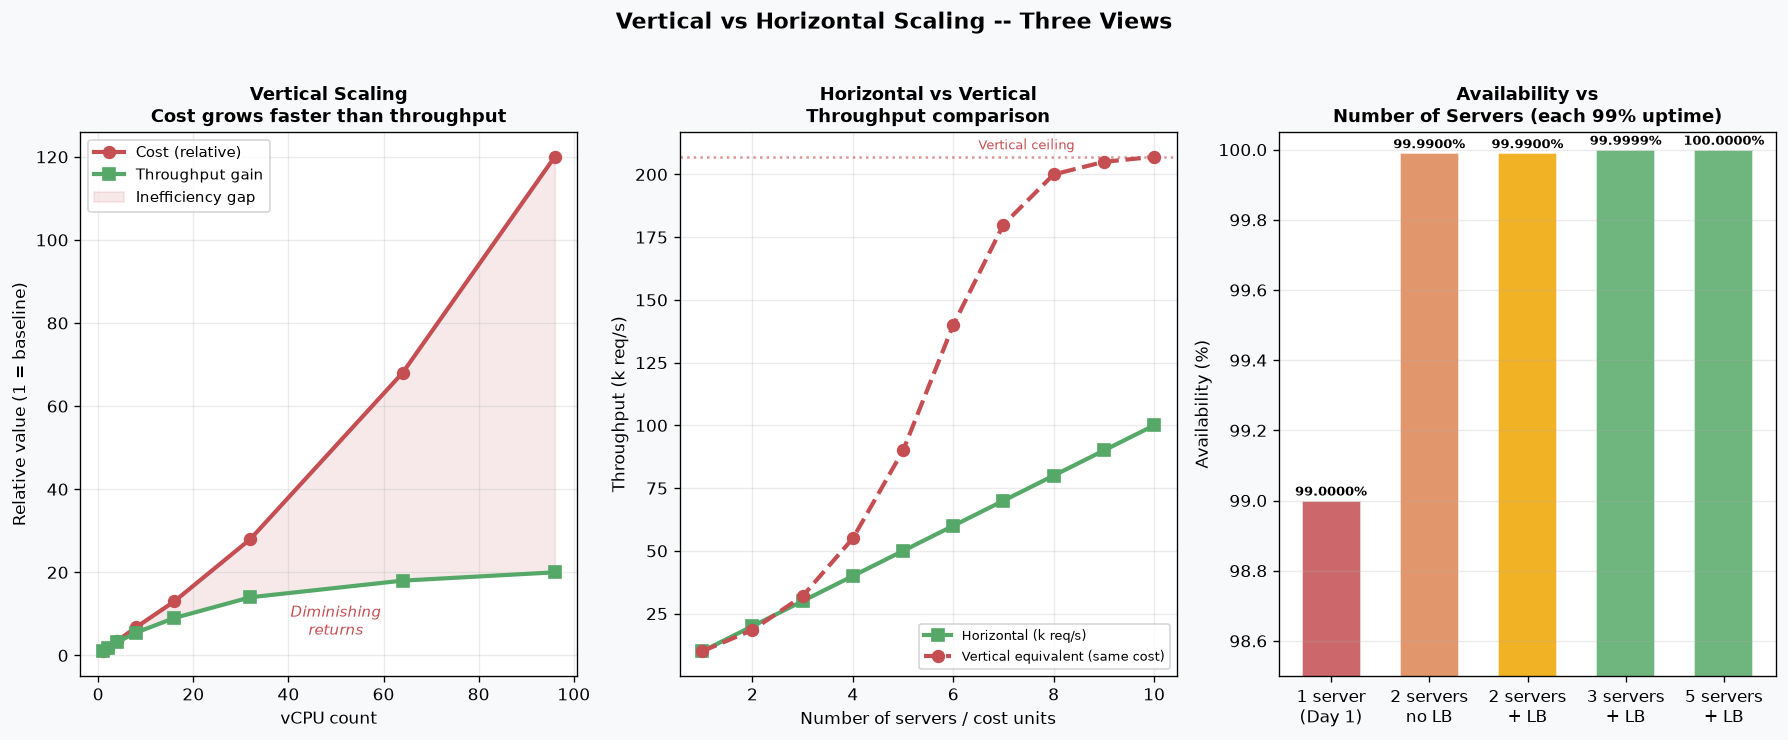

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(C_GRAY)

# Left: vertical scaling cost vs throughput
ax = axes[0]
vcpu = [1, 2, 4, 8, 16, 32, 64, 96]
cost_v       = [1, 1.9, 3.5, 6.8, 13, 28, 68, 120]
throughput_v = [1, 1.85, 3.2, 5.5, 9, 14, 18, 20]
ax.plot(vcpu, cost_v,       'o-', color=C_RED,   lw=2.5, ms=7, label='Cost (relative)')
ax.plot(vcpu, throughput_v, 's-', color=C_GREEN, lw=2.5, ms=7, label='Throughput gain')
ax.fill_between(vcpu, throughput_v, cost_v, alpha=0.12, color=C_RED,
                label='Inefficiency gap')
ax.set_xlabel('vCPU count')
ax.set_ylabel('Relative value (1 = baseline)')
ax.set_title('Vertical Scaling\nCost grows faster than throughput',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.text(50, 5, 'Diminishing\nreturns', ha='center', fontsize=9,
        color=C_RED, fontstyle='italic')

# Middle: horizontal vs vertical throughput
ax = axes[1]
n_servers = np.arange(1, 11)
h_throughput = n_servers * 10000
v_equivalent = [10000, 18500, 32000, 55000, 90000,
                140000, 180000, 200000, 205000, 207000]
ax.plot(n_servers, h_throughput/1000, 's-', color=C_GREEN, lw=2.5, ms=7,
        label='Horizontal (k req/s)')
ax.plot(n_servers, [v/1000 for v in v_equivalent], 'o--', color=C_RED,
        lw=2.5, ms=7, label='Vertical equivalent (same cost)')
ax.axhline(207, color=C_RED, lw=1.5, linestyle=':', alpha=0.6)
ax.text(6.5, 210, 'Vertical ceiling', fontsize=8, color=C_RED)
ax.set_xlabel('Number of servers / cost units')
ax.set_ylabel('Throughput (k req/s)')
ax.set_title('Horizontal vs Vertical\nThroughput comparison',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# Right: availability
ax = axes[2]
configs = ['1 server\n(Day 1)', '2 servers\nno LB', '2 servers\n+ LB',
           '3 servers\n+ LB', '5 servers\n+ LB']
p_up = [0.99, 1-(0.01**2), 1-(0.01**2), 1-(0.01**3), 1-(0.01**5)]
availability_pct = [p*100 for p in p_up]
colors_avail = [C_RED, C_ORANGE, C_GOLD, C_GREEN, C_GREEN]
bars = ax.bar(configs, availability_pct, color=colors_avail, alpha=0.85,
              edgecolor='white', width=0.6)
ax.set_ylabel('Availability (%)')
ax.set_ylim(98.5, 100.05)
ax.set_title('Availability vs\nNumber of Servers (each 99% uptime)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
for bar, v in zip(bars, availability_pct):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
            f'{v:.4f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Vertical vs Horizontal Scaling -- Three Views',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day3_scaling.png', dpi=130, bbox_inches='tight')
plt.show()


### What these three charts show

- **Left (cost vs throughput for vertical scaling)**: as you keep adding vCPUs to a single server, cost grows super-linearly (each hardware doubling gets more expensive at the top end) while throughput grows sub-linearly (memory bandwidth and I/O become the limiting factor). The red shaded area is wasted spend — you are paying more and getting proportionally less. This is the economic argument against infinite vertical scaling.

- **Middle (horizontal vs vertical throughput)**: horizontal scaling (green line) grows perfectly linearly with the number of servers — every added server contributes identically. Vertical scaling (red dashed line) mimics spending the same amount on a single larger instance — the curve flattens and hits a hard ceiling around 200k req/s, the maximum for the largest available cloud instance. There is literally nothing to buy after that. Horizontal has no such limit.

- **Right (availability math)**: this is the most important chart in Day 3 for interviews. With a single server at 99% uptime, you get 99% availability — 3.65 days of outage per year. A load-balanced pair of servers both at 99% uptime gives 99.99% availability (52 minutes/year) — because the system only fails if **both** fail simultaneously. Add a third and it becomes 99.9999% (31 seconds/year). Each additional server reduces downtime by two orders of magnitude. This is the mathematical proof that horizontal scaling is not just about capacity — it is the primary mechanism for achieving high availability.


## 4 — Failover: What Happens When a Server Goes Offline

> *"If server 1 goes offline, all the traffic will be routed to server 2. This prevents the website going offline."*

The key mechanism is the **health check** — the load balancer polls each server every 5–30 seconds with a lightweight HTTP probe (`GET /health`). If a server fails to respond N times in a row (configurable), it is removed from the rotation. No human intervention required.


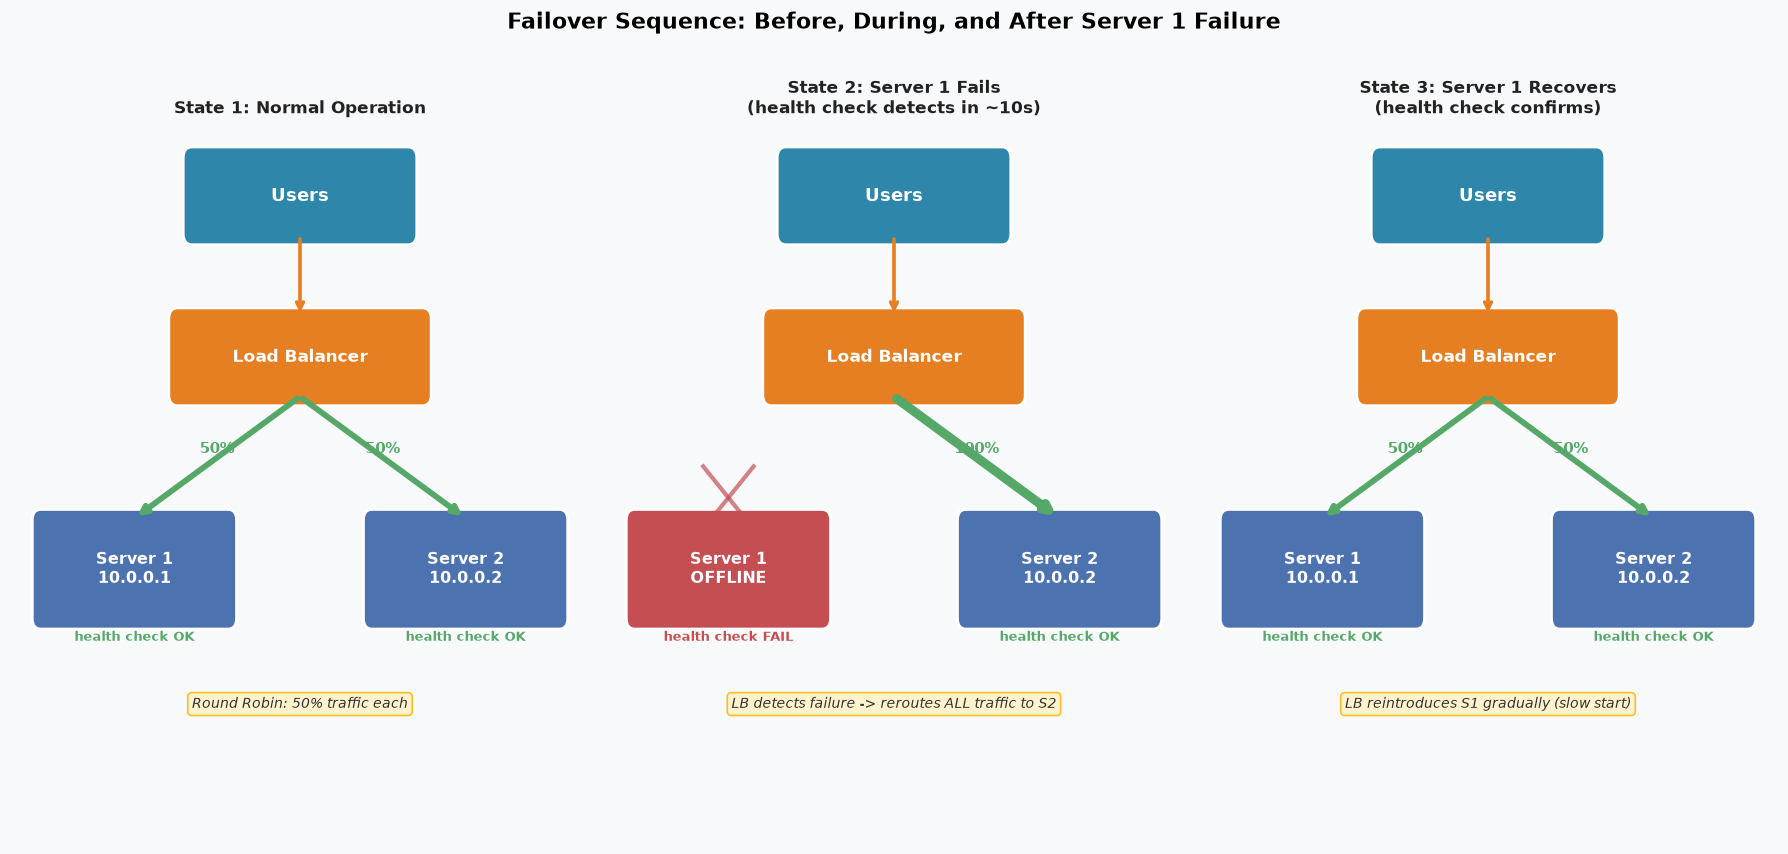

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)
plt.suptitle('Failover Sequence: Before, During, and After Server 1 Failure',
             fontsize=13, fontweight='bold', y=1.01)

def draw_lb_diagram(ax, title, s1_active, s2_active, s1_traffic, s2_traffic, note=''):
    ax.set_xlim(0, 8); ax.set_ylim(0, 8)
    ax.axis('off'); ax.set_facecolor(C_GRAY)
    ax.set_title(title, fontsize=10, fontweight='bold', color='#222', pad=8)

    # Users
    r = FancyBboxPatch((2.5, 6.8), 3.0, 0.85, boxstyle='round,pad=0.12',
                       facecolor=C_TEAL, edgecolor='white', lw=1.5)
    ax.add_patch(r)
    ax.text(4.0, 7.22, 'Users', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

    # Load Balancer
    r2 = FancyBboxPatch((2.3, 5.0), 3.4, 0.85, boxstyle='round,pad=0.12',
                        facecolor=C_LB, edgecolor='white', lw=1.5)
    ax.add_patch(r2)
    ax.text(4.0, 5.42, 'Load Balancer', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.annotate('', xy=(4.0, 5.88), xytext=(4.0, 6.78),
                arrowprops=dict(arrowstyle='->', color=C_LB, lw=2.2))

    # Server 1
    s1_color = C_BLUE if s1_active else C_RED
    s1_label = 'Server 1\n10.0.0.1' if s1_active else 'Server 1\nOFFLINE'
    r3 = FancyBboxPatch((0.4, 2.5), 2.6, 1.1, boxstyle='round,pad=0.12',
                        facecolor=s1_color, edgecolor='white', lw=1.8)
    ax.add_patch(r3)
    ax.text(1.7, 3.05, s1_label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')

    # Server 2
    s2_color = C_BLUE if s2_active else C_RED
    s2_label = 'Server 2\n10.0.0.2' if s2_active else 'Server 2\nOFFLINE'
    r4 = FancyBboxPatch((5.0, 2.5), 2.6, 1.1, boxstyle='round,pad=0.12',
                        facecolor=s2_color, edgecolor='white', lw=1.8)
    ax.add_patch(r4)
    ax.text(6.3, 3.05, s2_label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')

    # Traffic arrows
    for target_x, traffic, active in [(1.7, s1_traffic, s1_active),
                                      (6.3, s2_traffic, s2_active)]:
        if traffic > 0 and active:
            lw = 1.5 + traffic * 0.04
            ax.annotate('', xy=(target_x, 3.62), xytext=(4.0, 4.98),
                        arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=lw))
            ax.text((4.0+target_x)/2, 4.35, f'{traffic}%', ha='center',
                    fontsize=9, fontweight='bold', color=C_GREEN)
        elif not active and traffic == 0:
            ax.plot([target_x-0.35, target_x+0.35], [3.5, 4.2],
                    color=C_RED, lw=2.5, alpha=0.7)
            ax.plot([target_x-0.35, target_x+0.35], [4.2, 3.5],
                    color=C_RED, lw=2.5, alpha=0.7)

    # Health check labels
    for sx, active in [(1.7, s1_active), (6.3, s2_active)]:
        symbol = 'health check OK' if active else 'health check FAIL'
        color  = C_GREEN if active else C_RED
        ax.text(sx, 2.25, symbol, ha='center', fontsize=7.5,
                color=color, fontweight='bold')

    if note:
        ax.text(4.0, 1.5, note, ha='center', fontsize=8.5, color='#333',
                fontstyle='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD',
                          edgecolor='#FBBF24', lw=1.0))

draw_lb_diagram(axes[0], 'State 1: Normal Operation',
                s1_active=True, s2_active=True,
                s1_traffic=50,  s2_traffic=50,
                note='Round Robin: 50% traffic each')

draw_lb_diagram(axes[1], 'State 2: Server 1 Fails\n(health check detects in ~10s)',
                s1_active=False, s2_active=True,
                s1_traffic=0,    s2_traffic=100,
                note='LB detects failure -> reroutes ALL traffic to S2')

draw_lb_diagram(axes[2], 'State 3: Server 1 Recovers\n(health check confirms)',
                s1_active=True, s2_active=True,
                s1_traffic=50,  s2_traffic=50,
                note='LB reintroduces S1 gradually (slow start)')

plt.tight_layout()
plt.savefig('/tmp/sd_day3_failover.png', dpi=130, bbox_inches='tight')
plt.show()


### What this diagram shows
The three states of a load-balanced system during a server failure and recovery cycle.

- **State 1 (normal operation)**: both servers are healthy, the LB distributes 50/50. "health check OK" indicates the LB is actively polling each server. Green arrows show live traffic paths with equal thickness.

- **State 2 (failure)**: Server 1 goes offline (crash, OOM, bad deployment). The LB's health check fails N consecutive times — typically 3 failures at 10-second intervals = ~30 seconds to declare the server dead. Once declared, **100% of traffic routes to Server 2**. The X marks show the blocked path. The website stays online throughout. Note that Server 2 is now handling double the traffic — if it was already near capacity, this could cause a cascade failure. This is why you should run servers at <50% capacity, not 80-90%.

- **State 3 (recovery)**: Server 1 restarts and begins passing health checks. The LB reintroduces it gradually using a "slow start" window — it might start by sending 10% of traffic to S1, then ramp to 50% over 30–60 seconds. This prevents immediately overwhelming a freshly rebooted server that has empty caches and cold JVM/connection pools.

**Interview question to prepare for**: "What is the maximum downtime during a server failure?" Answer: the health check interval × failure threshold (e.g., 10s × 3 = 30 seconds of degraded-but-not-down behaviour, not a full outage since S2 keeps serving).


## 5 — Auto-Scaling: Dynamic Pool Growth

Auto-scaling is horizontal scaling on a schedule or metric trigger. Instead of manually adding servers, a cloud orchestrator monitors CPU/memory/request rate and automatically:
- **Scales out** (adds servers) when load exceeds a threshold (e.g., >70% CPU for 5 minutes)
- **Scales in** (removes servers) when load drops below a threshold (e.g., <30% CPU for 10 minutes)

The load balancer automatically registers new servers as they come online and drains traffic from servers being terminated.


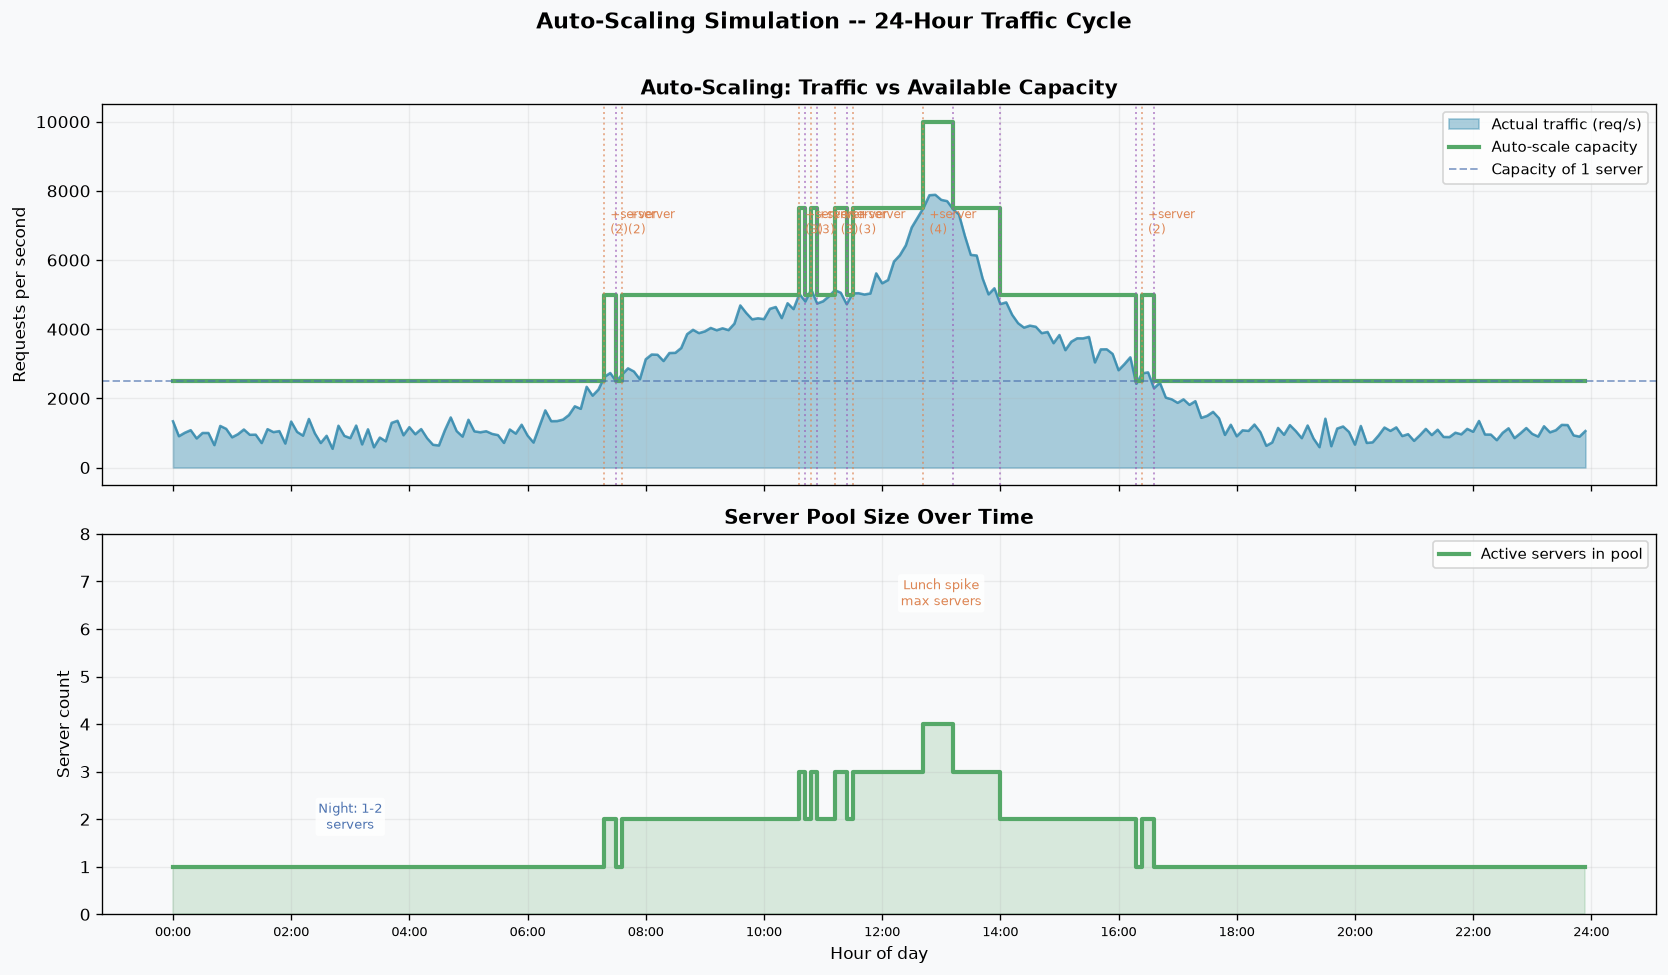

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor(C_GRAY)

hours = np.arange(0, 24, 0.1)

def traffic_pattern(t):
    base    = 1000
    day_add = 4000 * np.maximum(0, np.sin(np.pi * (t - 6) / 12))
    spike   = 3000 * np.exp(-0.5 * ((t - 13) / 0.5) ** 2)
    noise   = np.random.normal(0, 200, size=np.array(t).shape)
    return np.maximum(100, base + day_add + spike + noise)

np.random.seed(7)
traffic = traffic_pattern(hours)
capacity_per_server = 2500

auto_servers = np.ceil(traffic / capacity_per_server).astype(int)
auto_servers = np.clip(auto_servers, 1, 10)
capacity     = auto_servers * capacity_per_server

# Top: traffic vs capacity
ax1 = axes[0]
ax1.set_facecolor(C_GRAY)
ax1.fill_between(hours, 0, traffic, alpha=0.4, color=C_TEAL,
                 label='Actual traffic (req/s)')
ax1.plot(hours, traffic, color=C_TEAL, lw=1.5, alpha=0.8)
ax1.step(hours, capacity, color=C_GREEN, lw=2.5, where='post',
         label='Auto-scale capacity')
ax1.axhline(capacity_per_server, color=C_BLUE, lw=1.2, linestyle='--',
            alpha=0.6, label='Capacity of 1 server')
ax1.set_ylabel('Requests per second')
ax1.set_title('Auto-Scaling: Traffic vs Available Capacity',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.2)

prev = auto_servers[0]
for i in range(1, len(hours)):
    if auto_servers[i] > prev:
        ax1.axvline(hours[i], color=C_ORANGE, lw=1.2, alpha=0.6, linestyle=':')
        ax1.text(hours[i]+0.1, 7500, f'+server\n({auto_servers[i]})',
                 fontsize=7, color=C_ORANGE, va='top')
        prev = auto_servers[i]
    elif auto_servers[i] < prev:
        ax1.axvline(hours[i], color=C_PURPLE, lw=1.2, alpha=0.6, linestyle=':')
        prev = auto_servers[i]

# Bottom: server count
ax2 = axes[1]
ax2.set_facecolor(C_GRAY)
ax2.step(hours, auto_servers, color=C_GREEN, lw=2.5, where='post',
         label='Active servers in pool')
ax2.fill_between(hours, 0, auto_servers, alpha=0.2, color=C_GREEN, step='post')
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Server count')
ax2.set_title('Server Pool Size Over Time', fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, 25, 2))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 2)], fontsize=8)
ax2.legend(fontsize=9); ax2.grid(alpha=0.2)
ax2.set_ylim(0, 8)
ax2.text(13, 6.5, 'Lunch spike\nmax servers', ha='center', fontsize=8,
         color=C_ORANGE,
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, lw=0))
ax2.text(3, 1.8, 'Night: 1-2\nservers', ha='center', fontsize=8, color=C_BLUE,
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, lw=0))

plt.suptitle('Auto-Scaling Simulation -- 24-Hour Traffic Cycle',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day3_autoscale.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show
A simulated 24-hour auto-scaling cycle with a realistic daily traffic pattern (low overnight, builds through morning, lunch spike, evening decline).

- **Top chart (traffic vs capacity)**: the teal area is actual incoming traffic (req/s). The green stepped line is the total capacity of the auto-scaled server pool. Orange dotted verticals mark **scale-out events** (a server is added, with the new pool count annotated). Purple dotted verticals mark **scale-in events**. The capacity line must always stay above the traffic line — the auto-scaler's job is to ensure this gap never closes.

- **Bottom chart (server count)**: the pool starts at 2 servers at midnight, grows to a peak of 5–6 during the lunch hour spike, then descends back to 2 servers overnight. In a cloud environment this directly corresponds to billing — you pay per server-hour, so running 2 servers instead of 6 overnight saves 67% of compute cost for those hours.

**Three risks to know for interviews**:
1. **Boot lag**: a new cloud server takes 1–3 minutes to start. If traffic spikes faster, requests error before capacity arrives. Solution: predictive scaling or a standing minimum fleet.
2. **Thrashing**: scale out at 70%, scale in at 65% = constant oscillation. Solution: hysteresis — scale out at 70%, scale in only at 30%.
3. **Stateful sessions**: if a server is terminated while holding a user's session in memory, the user gets logged out. Solution: externalise session state to a shared cache (covered in a later day).


## 6 — Architecture Evolution: Day 1 → Day 2 → Day 3


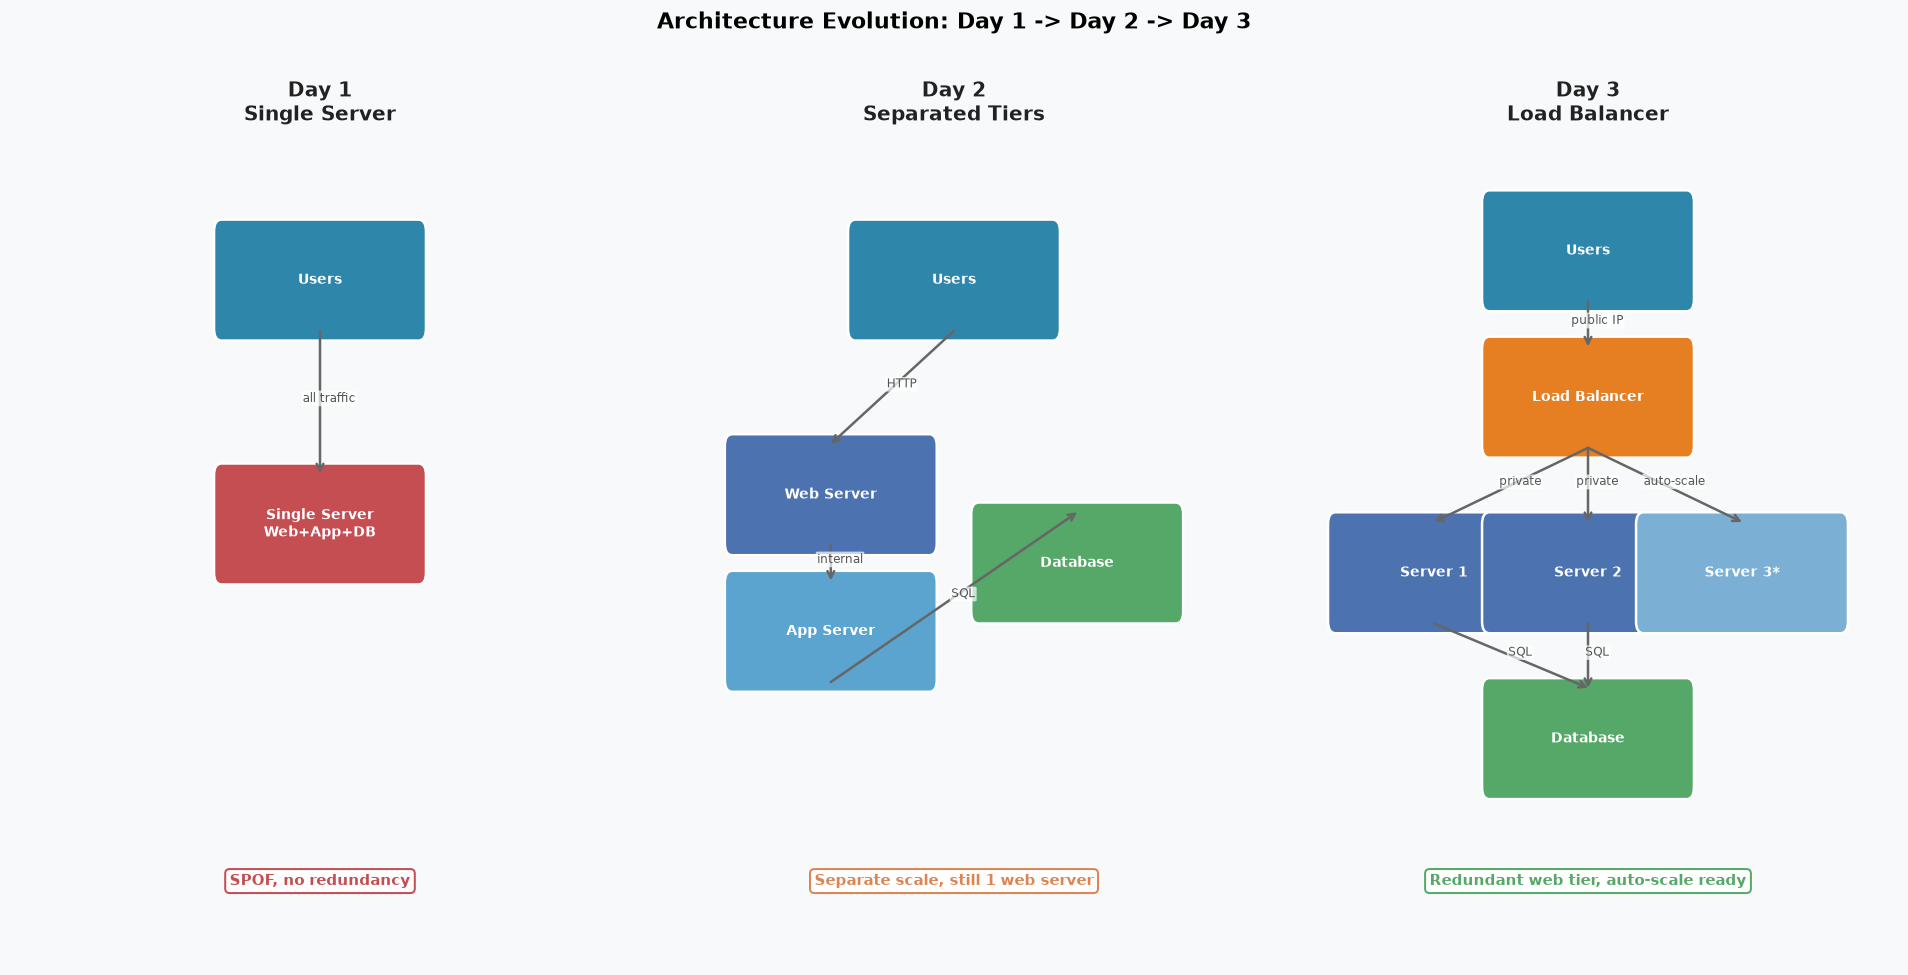

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
fig.patch.set_facecolor(C_GRAY)
plt.suptitle('Architecture Evolution: Day 1 -> Day 2 -> Day 3',
             fontsize=13, fontweight='bold', y=1.01)

configs = [
    ('Day 1\nSingle Server',
     [('Users',          5, 7.0, C_TEAL),
      ('Single Server\nWeb+App+DB', 5, 4.5, C_RED)],
     [('Users', 'Single Server\nWeb+App+DB', 'all traffic')],
     'SPOF, no redundancy', C_RED),

    ('Day 2\nSeparated Tiers',
     [('Users',      5, 7.0, C_TEAL),
      ('Web Server', 3, 4.8, C_BLUE),
      ('App Server', 3, 3.4, '#5BA4CF'),
      ('Database',   7, 4.1, C_GREEN)],
     [('Users',      'Web Server', 'HTTP'),
      ('Web Server', 'App Server', 'internal'),
      ('App Server', 'Database',  'SQL')],
     'Separate scale, still 1 web server', C_ORANGE),

    ('Day 3\nLoad Balancer',
     [('Users',         5,   7.3, C_TEAL),
      ('Load Balancer', 5,   5.8, C_LB),
      ('Server 1',      2.5, 4.0, C_BLUE),
      ('Server 2',      5,   4.0, C_BLUE),
      ('Server 3*',     7.5, 4.0, '#7BAFD4'),
      ('Database',      5,   2.3, C_GREEN)],
     [('Users',         'Load Balancer', 'public IP'),
      ('Load Balancer', 'Server 1',      'private'),
      ('Load Balancer', 'Server 2',      'private'),
      ('Load Balancer', 'Server 3*',     'auto-scale'),
      ('Server 1',      'Database',      'SQL'),
      ('Server 2',      'Database',      'SQL')],
     'Redundant web tier, auto-scale ready', C_GREEN),
]

for ax, (title, nodes, edges, note, note_color) in zip(axes, configs):
    ax.set_xlim(0, 10); ax.set_ylim(0, 8.5)
    ax.axis('off'); ax.set_facecolor(C_GRAY)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#222', pad=8)

    positions = {}
    for lbl, x, y, color in nodes:
        positions[lbl] = (x, y)
        r = FancyBboxPatch((x-1.6, y-0.5), 3.2, 1.0,
                           boxstyle='round,pad=0.12',
                           facecolor=color, edgecolor='white', lw=1.5)
        ax.add_patch(r)
        ax.text(x, y, lbl, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='white')

    for (a, b, lbl) in edges:
        if a in positions and b in positions:
            x1, y1 = positions[a]
            x2, y2 = positions[b]
            ax.annotate('', xy=(x2, y2+0.52), xytext=(x1, y1-0.52),
                        arrowprops=dict(arrowstyle='->', color='#666', lw=1.5,
                                        shrinkA=0, shrinkB=0))
            ax.text((x1+x2)/2+0.15, (y1+y2)/2, lbl, ha='center',
                    fontsize=7, color='#555',
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                              alpha=0.7, lw=0))

    ax.text(5, 0.8, note, ha='center', fontsize=9, color=note_color,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=note_color, lw=1.2))

plt.tight_layout()
plt.savefig('/tmp/sd_day3_evolution.png', dpi=130, bbox_inches='tight')
plt.show()


### What this diagram shows
The three-day architectural progression side by side, making the evolution explicit.

- **Day 1 (left, red)**: everything on one box. Single point of failure — the server goes down, the site goes down. No redundancy whatsoever.
- **Day 2 (centre, orange)**: web tier and data tier are separated into independent machines. Better resource isolation, but still only one web server — still a single point of failure for the web layer.
- **Day 3 (right, green)**: a load balancer sits in front of two (or more) web servers. Server 3* (dimmed) represents an auto-scaled server that appears only under load. Both Server 1 and Server 2 query the same database — which means **the database is now the next single point of failure**.

**The asterisk notation**: in system design interviews, asterisked or dashed-border nodes signal "this component exists conditionally". It shows you are thinking about cost and necessity, not just drawing everything at maximum complexity.

**What's still missing**: the database is a single shared instance. If it goes down, both web servers return errors. This is what Day 4 (Database Replication) solves.


## 7 — Key Takeaways

```
Day 3 Principles
================

1. The load balancer IS the public IP.
   Web servers move behind private IPs -- unreachable from the internet.
   Security and routing in one architectural decision.

2. Horizontal scaling has no ceiling; vertical scaling does.
   Vertical: add CPU/RAM. Simple but finite and expensive at scale.
   Horizontal: add servers. Unlimited, but requires stateless apps.

3. Failover is automatic, not manual.
   Health checks detect a dead server within seconds.
   Traffic re-routes without a human intervening.
   Design for this: keep servers below 50% normal load.

4. Auto-scaling is horizontal scaling on a metric trigger.
   Scale out when load rises. Scale in when load falls.
   Pay only for what you use -- the cloud billing model.

5. Availability scales multiplicatively with redundancy.
   1 server at 99% uptime = 87h downtime/year.
   2 servers at 99% uptime behind LB = 52 min/year.
   3 servers = 31 seconds/year.

6. The new bottleneck after Day 3: the database.
   Web servers are now stateless and horizontally scalable.
   The database is still a single machine -- every web server queries it.
   Day 4 tackles database replication to fix this.
```

### What Day 4 will cover
**Database Replication** — one primary (handles writes) + multiple read replicas (handle reads).
This is how you stop the database being the new single point of failure,
and how you scale read-heavy workloads independently of write throughput.


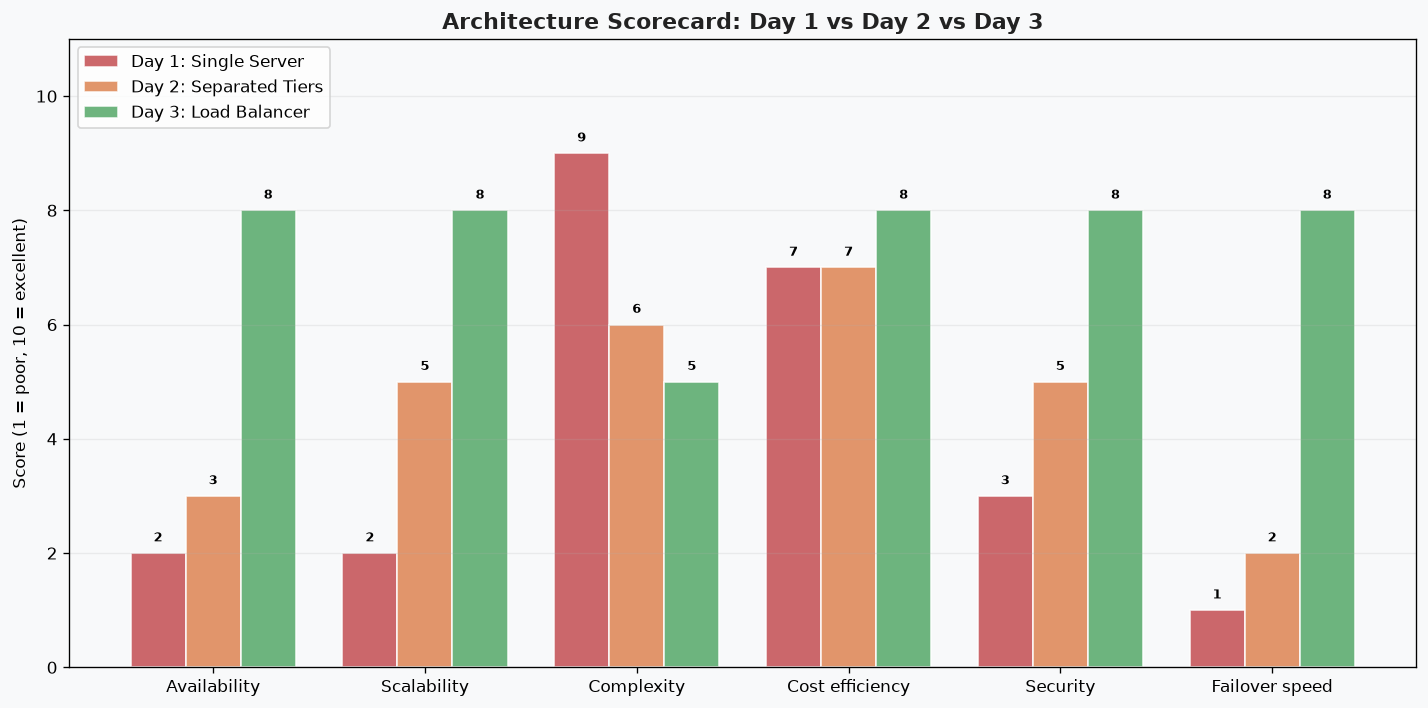

Day 3 complete.
Next: Day 4 -- Database Replication (primary + read replicas)


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor(C_GRAY)
fig.patch.set_facecolor(C_GRAY)

dimensions = ['Availability', 'Scalability', 'Complexity',
              'Cost efficiency', 'Security', 'Failover speed']
day1 = [2, 2, 9, 7, 3, 1]
day2 = [3, 5, 6, 7, 5, 2]
day3 = [8, 8, 5, 8, 8, 8]

x = np.arange(len(dimensions))
w = 0.26

b1 = ax.bar(x - w, day1, width=w, color=C_RED,    alpha=0.85,
            edgecolor='white', label='Day 1: Single Server')
b2 = ax.bar(x,     day2, width=w, color=C_ORANGE,  alpha=0.85,
            edgecolor='white', label='Day 2: Separated Tiers')
b3 = ax.bar(x + w, day3, width=w, color=C_GREEN,   alpha=0.85,
            edgecolor='white', label='Day 3: Load Balancer')

ax.set_xticks(x)
ax.set_xticklabels(dimensions, fontsize=10)
ax.set_ylabel('Score (1 = poor, 10 = excellent)')
ax.set_ylim(0, 11)
ax.set_title('Architecture Scorecard: Day 1 vs Day 2 vs Day 3',
             fontsize=13, fontweight='bold', color='#222')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.2)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.15,
                str(int(bar.get_height())),
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/sd_day3_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()

print("Day 3 complete.")
print("Next: Day 4 -- Database Replication (primary + read replicas)")


### What this scorecard shows
A three-day progression comparison across six dimensions that matter most in production.

- **Availability (2 → 3 → 8)**: the biggest single-day jump. Adding a second server behind a load balancer multiplies uptime from 99% to 99.99% — the mathematical result of redundancy.
- **Scalability (2 → 5 → 8)**: horizontal scaling via the load balancer means you can add servers on demand. The remaining gap to 10 is the database — it still cannot scale this way.
- **Complexity (9 → 6 → 5)**: slightly lower complexity than Day 2 because cloud-managed load balancers (AWS ALB, GCP HTTPS LB, NGINX) handle health checks, SSL, and routing with minimal configuration. You trade a few config lines for significant reliability gains.
- **Cost efficiency (7 → 7 → 8)**: auto-scaling means you pay for servers only when traffic demands them. Commodity horizontal servers are cheaper per unit of throughput than vertical scaling at the high end.
- **Security (3 → 5 → 8)**: web servers are no longer publicly addressable. SSL termination at the LB centralises certificate management. DDoS absorption is easier with a single ingress point.
- **Failover speed (1 → 2 → 8)**: health-check-driven rerouting happens in seconds (the health check interval × failure count), with no human on-call action required.

**The gap to watch**: scalability scores 8, not 10. The database is the next bottleneck — a single write master that every web server queries. That ceiling is what Day 4 breaks through.
